# 09. 원장은 학습에 들어갈 모양인가 — 백테스트 원장 계약을 실행으로 잰다

> 2026-09-06 최초 · **2026-09-08 개정(축 정정)** · 이동원 · 결론 문서:
> [평가파트 v1.1 §5](../../docs/평가파트/version1.1/동적기준선_ARIMA동반_백테스트원장.md) ·
> 검증기 [`supply/backtest_ledger.py`](../../supply/backtest_ledger.py) ·
> 시험 [`tests/test_backtest_ledger_contract.py`](../../tests/test_backtest_ledger_contract.py) ·
> 이슈 [#110](https://github.com/devlee328288/Alpha_Stack/issues/110) ·
> [#172](https://github.com/devlee328288/Alpha_Stack/issues/172) ·
> [#176](https://github.com/devlee328288/Alpha_Stack/issues/176)

> **2026-09-08 개정 — 이 노트북의 결론 하나가 뒤집혔습니다.**
> 처음 쓸 때 *"실현수익률은 종가로 다시 계산한 값과 일치한다"* 를 ✅ 로 적었습니다.
> 그런데 **종가로 재는 것 자체가 틀렸습니다.** ADR-0002 는 `T+1 시가 → T+6 시가` 로 정해
> 두었고 라벨도 체결도 그 축인데, 원장과 검증기만 종가축이었습니다. 오준영 님이 #172 에서
> 찾았습니다. 검증기는 고쳤고(이 노트북), 원장 생성 쪽은 #176 으로 넘겼습니다.

---

## 이 노트북이 답하는 것

> **강민석 님이 PR #131 로 넣으신 원장(`signal_log` · `trade_log`)이, 데이터 파트가 #110 에서
> 여쭌 모양대로 나오는가 — 그리고 그것이 학습에 되먹일 수 있는 모양인가.**

PR 본문은 "칸 9개 추가 · HF 업로드 구현" 이라 적혀 있습니다. 옮겨 적기 전에 **실행으로**
셉니다. 정규식으로 센 칸 수가 한 번 틀렸기 때문입니다(23 이라 적었다가 22 였습니다).

| 잰 것 | 결과 |
|---|---|
| `signal_log` 칸 | **17** (8 + 9) |
| `trade_log` 칸 | **22** (13 + 9) — v1.0 문서의 "14칸" 은 오기 |
| 행 수 | 거래일 − 1 |
| `realized_return_5d` | 🔴 **종가축이라 틀렸다** — 시가축이어야 한다 (#172 · 아래 6절) |
| HF 원장 2종 | ⚠️ **올라왔다**(09-08 06:14) — 그런데 종가축이라 검증기가 붉게 잡는다 |
| 선언된 환경(.venv)에서 import | 🔴 **안 된다** — `datasets` 를 최상단에서 import

---

## 0. 준비

`backtest_strategies.py` 는 최상단에서 `from datasets import Dataset` 을 합니다. `pyproject.toml` 이
`datasets` 를 일부러 안 넣어서(74행) 선언된 환경에서는 이 모듈이 import 되지 않고, 이 세션의
anaconda 파이썬에서는 pandas dist-info 가 둘이라 `datasets` 쪽이 깨집니다. 여기서는 import 가
실패할 때만 빈 대역을 끼워 `run_backtest` 만 읽습니다 — 업로드 경로는 부르지 않습니다.

In [1]:
import importlib
import sys
import types
from pathlib import Path

import numpy as np
import pandas as pd

ROOT = Path.cwd().parent.parent
sys.path.insert(0, str(ROOT))

try:
    import datasets  # noqa: F401
    print("datasets: 진짜 모듈")
except Exception as e:  # noqa: BLE001
    stub = types.ModuleType("datasets")
    stub.Dataset = object
    sys.modules["datasets"] = stub
    print(f"datasets import 실패({type(e).__name__}) → 대역을 끼움")

bt = importlib.import_module("backtest.backtest_strategies")
from supply import backtest_ledger as bl  # noqa: E402

print("backtest_strategies:", Path(bt.__file__).relative_to(ROOT))

datasets: 진짜 모듈


backtest_strategies: backtest\backtest_strategies.py


---

## 1. 합성 시세 60거래일로 칸을 센다

예측 함수는 라벨과 확률을 함께 돌려주는 새 규약으로 씁니다. 확률은 상수가 아니게 둡니다.

In [2]:
days = pd.bdate_range("2024-06-03", periods=60)
rng = np.random.default_rng(0)
close = pd.Series(100 * np.cumprod(1 + rng.normal(0, 0.01, len(days))), index=days)
# 시가는 전일 종가와 다르다 — 밤사이 갭이 있다. 갭을 빼면 open[t+1] == close[t] 가 되어
# 시가축과 종가축이 우연히 같아지고, 축이 어긋나도 이 노트북이 못 잡는다.
gap = 1.0 + np.random.default_rng(97).normal(0, 0.004, len(close))
market = pd.DataFrame({"open": close.shift(1).fillna(close.iloc[0]).to_numpy() * gap,
                       "close": close.to_numpy()}, index=days)


def predict(date, market_data):
    i = market_data.index.get_loc(date)
    return bl.LABELS[i % 3], {"p_up": 0.5, "p_flat": 0.3, "p_down": 0.2}


res = bt.run_backtest(market, days[0], days[-1], predict, strategy="A",
                      model_id="probe-v0", run_id="run_probe")
sig, trd = res["signal_log"], res["trade_log"]
print("signal_log:", sig.shape, "| trade_log:", trd.shape)
print("signal_log 칸이 계약과 같다:", list(sig.columns) == list(bl.SIGNAL_LOG_COLUMNS))
print("trade_log  칸이 계약과 같다:", list(trd.columns) == list(bl.TRADE_LOG_COLUMNS))
sig.head(3)

signal_log: (59, 17) | trade_log: (39, 22)
signal_log 칸이 계약과 같다: True
trade_log  칸이 계약과 같다: True


,prediction_date,execution_date,signal,consecutive_up,consecutive_down,requested_trade_ratio,actual_trade_value,position_ratio_after,code,p_up,p_flat,p_down,realized_return_5d,model_id,model_rev,run_id,cost_rate
0,2024-06-03,2024-06-04,상승,1,0,0.2,20.000000,0.200040,KOSPI200,0.5,0.3,0.2,0.004358,probe-v0,v0,run_probe,0.001
1,2024-06-04,2024-06-05,중립,0,0,0.0,0.000000,0.198818,KOSPI200,0.5,0.3,0.2,0.018801,probe-v0,v0,run_probe,0.001
2,2024-06-05,2024-06-06,하락,0,1,-0.2,19.929819,0.000000,KOSPI200,0.5,0.3,0.2,0.021905,probe-v0,v0,run_probe,0.001


### 행 수 · 체결일 · 실현수익률

마지막 거래일은 다음 날 체결이 없어 원장에 남지 않습니다 — 그래서 **거래일 − 1**.
`realized_return_5d` 는 **`시가[t+6] / 시가[t+1] − 1`** 이어야 합니다(ADR-0002). 청산일 t+6 이
자료 밖인 마지막 **다섯** 행이 NaN 입니다 — 종가축이던 때보다 한 행 더 빕니다.

아래에서 원장 값과 **두 축을 다 대조**합니다. 원장(강민석 님 코드)은 아직 종가축이라
시가축과 어긋나는 것이 보일 것입니다 — 그것이 #176 입니다.

In [3]:
pos = {d: i for i, d in enumerate(days)}
gaps = pd.Series([pos[e] - pos[p]
                  for p, e in zip(sig["prediction_date"], sig["execution_date"], strict=True)])
시가축 = bl.recompute_realized_return(sig["prediction_date"], market["open"])
종가축 = pd.Series([(close.to_numpy()[i + 5] / close.to_numpy()[i] - 1.0)
                  if i + 5 < len(close) else np.nan
                  for i in (pos[d] for d in sig["prediction_date"])])
print(f"행 수 {len(sig)} = 거래일 {len(days)} − 1 :", len(sig) == len(days) - 1)
print("체결일 − 예측일 (거래일 수) 고유값:", sorted(gaps.unique().tolist()))
print("실현수익률 NaN 행:", int(sig["realized_return_5d"].isna().sum()))
rr = sig["realized_return_5d"].reset_index(drop=True)
for 이름, 축 in (("시가축 open[t+6]/open[t+1]", 시가축), ("종가축 close[t+5]/close[t]", 종가축)):
    m = rr.notna() & 축.notna()
    print(f"  원장 vs {이름}: 최대차 {float((rr - 축).abs()[m].max()):.6%}")

행 수 59 = 거래일 60 − 1 : True
체결일 − 예측일 (거래일 수) 고유값: [1]
실현수익률 NaN 행: 4
  원장 vs 시가축 open[t+6]/open[t+1]: 최대차 1.400857%
  원장 vs 종가축 close[t+5]/close[t]: 최대차 0.000000%


---

## 2. 검증기가 규격 그대로 나온 원장을 통과시키는가

In [4]:
r = bl.verify_execution_log(sig, open_prices=market["open"])
t = bl.verify_trade_log(trd, open_prices=market["open"])
print("signal_log problems:", r["problems"], "| warnings:", r["warnings"])
print("trade_log  problems:", t["problems"])
r["summary"]

signal_log problems: ['실현수익률이 시가[T+1]→시가[T+6] 로 다시 계산한 값과 다르다: 54행 (종가축으로 적힌 원장이면 #176 을 보라)', '실현수익률의 결측 자리가 시가로 계산한 것과 어긋난다: 1행'] | warnings: ['확률이 전 행에서 상수다 — 학습에 정보가 없다 ([0.5, 0.3, 0.2])', "계산 기준 칸 ('return_price_basis', 'entry_offset', 'exit_offset') 이 없다 — 가격을 안 주면 축이 달라도 못 잡는다"]
trade_log  problems: ['실현수익률이 시가[T+1]→시가[T+6] 로 다시 계산한 값과 다르다: 36행 (종가축으로 적힌 원장이면 #176 을 보라)', '실현수익률의 결측 자리가 시가로 계산한 것과 어긋난다: 1행']


{'kind': 'signal',
 'holdout_start': '20240901',
 'missing_columns': [],
 'extra_columns': [],
 'prob_distinct_rows': 1,
 'holdout_rows': 0,
 'realized_nan_rows': 4,
 'holdout_peek_rows': 0,
 'basis_columns': [],
 'signal_counts': {'상승': 20, '중립': 20, '하락': 19},
 'run_ids': 1,
 'model_ids': ['probe-v0']}

---

## 3. 실제 개발구간 파일로 — 강민석 님이 쓰시는 그 파일

HF `small/features_labels_kospi200_dev.csv` 를 **캐시에서** 읽습니다(다운로드 없음). 예측 함수는
저장소의 `predict_5d_after` 그대로 — 지금은 랜덤 예측이고 확률이 상수 0.33/0.34/0.33 입니다.

In [5]:
from huggingface_hub import try_to_load_from_cache

p = try_to_load_from_cache("qurious-quant/alphastack-krx-dev",
                           "small/features_labels_kospi200_dev.csv", repo_type="dataset")
df = pd.read_csv(p)
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date").set_index("date")
print(f"행 {len(df):,} · {df.index.min().date()} ~ {df.index.max().date()}")

real = bt.run_backtest(df, df.index[0], df.index[-1], bt.predict_5d_after,
                       strategy="A", model_id="random-v0", run_id="run_probe_real")
s = real["signal_log"]
print("signal_log:", s.shape, "| trade_log:", real["trade_log"].shape)
print("signal 분포:", s["signal"].value_counts().to_dict())
print("p_* 고유 조합:", s[["p_up", "p_flat", "p_down"]].drop_duplicates().values.tolist())

행 3,553 · 2010-03-30 ~ 2024-08-22


signal_log: (3552, 17) | trade_log: (2034, 22)
signal 분포: {'하락': 1208, '중립': 1183, '상승': 1161}
p_* 고유 조합: [[0.33, 0.34, 0.33]]


In [6]:
rr = bl.verify_execution_log(s, open_prices=df["open"])
print("problems:", rr["problems"])
print("warnings:", rr["warnings"])
{k: v for k, v in rr["summary"].items() if k != "signal_counts"}

problems: ['실현수익률이 시가[T+1]→시가[T+6] 로 다시 계산한 값과 다르다: 3,547행 (종가축으로 적힌 원장이면 #176 을 보라)', '실현수익률의 결측 자리가 시가로 계산한 것과 어긋난다: 1행']
warnings: ['확률이 전 행에서 상수다 — 학습에 정보가 없다 ([0.33, 0.34, 0.33])', "계산 기준 칸 ('return_price_basis', 'entry_offset', 'exit_offset') 이 없다 — 가격을 안 주면 축이 달라도 못 잡는다"]


{'kind': 'signal',
 'holdout_start': '20240901',
 'missing_columns': [],
 'extra_columns': [],
 'prob_distinct_rows': 1,
 'holdout_rows': 0,
 'realized_nan_rows': 4,
 'holdout_peek_rows': 0,
 'basis_columns': [],
 'run_ids': 1,
 'model_ids': ['random-v0']}

규격은 깨끗합니다. 경고 하나 — **확률이 전 행 상수**라 지금 원장을 되먹여도 배울 것이 없습니다.
그래서 되먹임 피처는 합의대로 2차이고, 1차는 **모양을 고정해 두는 것**까지입니다.
오준영 님 모델이 붙어 `predict_proba()` 가 세 칸을 채우는 순간 이 경고가 사라집니다.

---

## 4. 검증기가 잡아야 할 것을 잡는가 — 홀드아웃을 넘겨 돌리면

개발구간 예측이 봉인 구간(20240901~) 가격을 엿보는 두 가지 방식을 다 잡아야 합니다.
① 예측일 자체가 봉인 안 · ② 예측일은 개발구간인데 **청산일 t+6 시가**가 봉인 안.

In [7]:
d2 = pd.bdate_range("2024-08-12", periods=30)        # 08-12 ~ 09-20
c2 = pd.Series(100 * np.cumprod(1 + rng.normal(0, 0.01, len(d2))), index=d2)
g2 = 1.0 + np.random.default_rng(98).normal(0, 0.004, len(c2))
m2 = pd.DataFrame({"open": c2.shift(1).fillna(c2.iloc[0]).to_numpy() * g2,
                   "close": c2.to_numpy()}, index=d2)
leak = bt.run_backtest(m2, d2[0], d2[-1], predict, strategy="A")["signal_log"]
v = bl.verify_execution_log(leak, open_prices=m2["open"])
print("예측일이 봉인 안인 행:", v["summary"]["holdout_rows"])
print("청산일 t+6 이 봉인 안인 행:", v["summary"]["holdout_peek_rows"])
for p_ in v["problems"]:
    print(" 🔴", p_)

예측일이 봉인 안인 행: 14
청산일 t+6 이 봉인 안인 행: 15
 🔴 예측일이 홀드아웃(20240901~) 안인 행: 14
 🔴 실현수익률이 시가[T+1]→시가[T+6] 로 다시 계산한 값과 다르다: 24행 (종가축으로 적힌 원장이면 #176 을 보라)
 🔴 실현수익률의 결측 자리가 시가로 계산한 것과 어긋난다: 1행
 🔴 실현수익률이 홀드아웃 시가를 엿본 행: 15


---

## 5. HF 에 원장이 있나 — **오늘 올라왔습니다.** 그런데 축이 다릅니다

2026-09-06 에 이 노트북을 처음 쓸 때는 없었습니다. **09-08 06:14 UTC 에 올라왔습니다.**
받아서 어느 축으로 적혔는지 셉니다.

In [8]:
from huggingface_hub import HfApi, hf_hub_download

api = HfApi()
info = api.dataset_info(bl.HF_EXECUTION_LOG)
print("마지막 갱신:", info.lastModified)
files = [f.rfilename for f in info.siblings if f.rfilename.endswith(".parquet")]
led = pd.read_parquet(hf_hub_download(bl.HF_EXECUTION_LOG, files[0], repo_type="dataset"))
print(f"{files[0]} - {len(led):,}행 · {len(led.columns)}칸")
print("예측일:", led["prediction_date"].min(), "~", led["prediction_date"].max())

마지막 갱신: 2026-09-08 06:14:26+00:00
data/train-00000-of-00001.parquet - 4,836행 · 19칸
예측일: 2023-01-02 ~ 2024-08-21


### 어느 축으로 적혔나 — 지수 실제 가격으로 두 축을 다 계산해 맞춰 봅니다

In [9]:
import sqlite3

con = sqlite3.connect(ROOT / "data" / "krx_cache.db")
px = pd.read_sql("select bas_dd, open, close from index_price "
                 "where index_name = '코스피 200' and index_class = 'KOSPI' order by bas_dd", con)
con.close()
px = px[(px["open"] > 0) & (px["close"] > 0)].reset_index(drop=True)
px["종가축"] = px["close"].shift(-5) / px["close"] - 1.0
px["시가축"] = px["open"].shift(-6) / px["open"].shift(-1) - 1.0

m = led[["prediction_date", "realized_return_5d"]].copy()
m["bas_dd"] = pd.to_datetime(m["prediction_date"]).dt.strftime("%Y%m%d")
m = m.merge(px[["bas_dd", "종가축", "시가축"]], on="bas_dd", how="left").dropna()
print(f"대조 가능한 행: {len(m):,}")
for 이름 in ("종가축", "시가축"):
    diff = (m["realized_return_5d"] - m[이름]).abs()
    print(f"  {이름}과 1e-9 안에서 일치: {int((diff < 1e-9).sum()):,} / {len(m):,} "
          f"({(diff < 1e-9).mean():.2%}) · 평균차 {diff.mean():.4%}")

대조 가능한 행: 4,788
  종가축과 1e-9 안에서 일치: 4,788 / 4,788 (100.00%) · 평균차 0.0000%
  시가축과 1e-9 안에서 일치: 0 / 4,788 (0.00%) · 평균차 0.8196%


**올라간 원장은 100% 종가축입니다.** 시가축과는 한 행도 맞지 않습니다.

그래서 지금 검증기에 그대로 넣으면 **붉게 잡힙니다** — 그게 맞는 동작입니다.

In [10]:
hf_led = led.copy()
hf_led["prediction_date"] = pd.to_datetime(hf_led["prediction_date"])
opens = px.set_index(pd.to_datetime(px["bas_dd"]))["open"]
v_hf = bl.verify_execution_log(hf_led[list(bl.SIGNAL_LOG_COLUMNS)], open_prices=opens)
print("problems:")
for 문제 in v_hf["problems"]:
    print("  🔴", 문제)
print("warnings:")
for 경고 in v_hf["warnings"]:
    print("  ⚠️", 경고)

problems:
  🔴 실현수익률이 시가[T+1]→시가[T+6] 로 다시 계산한 값과 다르다: 4,788행 (종가축으로 적힌 원장이면 #176 을 보라)
  🔴 실현수익률의 결측 자리가 시가로 계산한 것과 어긋난다: 48행
warnings:
  ⚠️ 확률이 전 행에서 상수다 — 학습에 정보가 없다 ([0.33, 0.34, 0.33])
  ⚠️ 계산 기준 칸 ('return_price_basis', 'entry_offset', 'exit_offset') 이 없다 — 가격을 안 주면 축이 달라도 못 잡는다


---

## 6. 두 축은 얼마나 다른가 — 지수 전 구간으로 그려 봅니다

"간격이 같은 5거래일인데 얼마나 다르겠나" 를 눈으로 봅니다. 상관은 높은데 **라벨은 자주
갈립니다** — 그 사이가 이 버그의 크기입니다.

행 4,099 · 값이 정확히 같은 행 0
라벨 일치 78.36% · 불일치 887행
상관 0.9118 · 평균 절대차 0.8168%


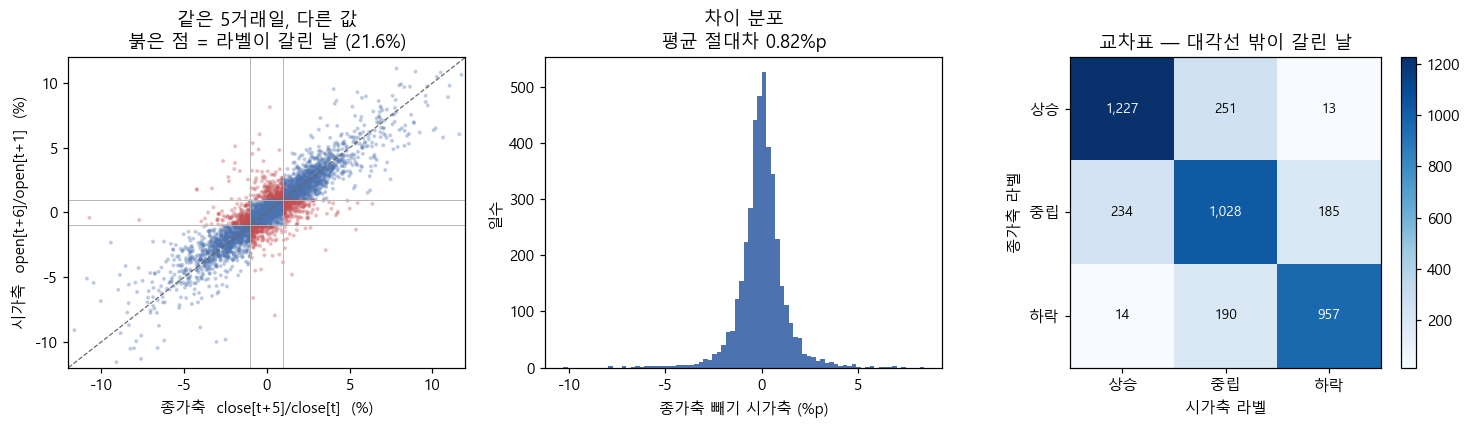

In [11]:
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.dpi"] = 110

BAND = 0.01
d = px.dropna(subset=["종가축", "시가축"]).copy()


def 라벨(x):
    return np.select([x > BAND, x < -BAND], ["상승", "하락"], default="중립")


d["종가라벨"], d["시가라벨"] = 라벨(d["종가축"]), 라벨(d["시가축"])
일치 = (d["종가라벨"] == d["시가라벨"])
print(f"행 {len(d):,} · 값이 정확히 같은 행 {int((d['종가축'] == d['시가축']).sum()):,}")
print(f"라벨 일치 {일치.mean():.2%} · 불일치 {int((~일치).sum()):,}행")
print(f"상관 {d['종가축'].corr(d['시가축']):.4f} · 평균 절대차 "
      f"{(d['종가축'] - d['시가축']).abs().mean():.4%}")

fig, ax = plt.subplots(1, 3, figsize=(13.5, 4.0))
lim = 12

ax[0].scatter(d["종가축"] * 100, d["시가축"] * 100, s=3, alpha=0.25,
              c=np.where(일치, "#4C72B0", "#C44E52"))
ax[0].plot([-lim, lim], [-lim, lim], lw=0.8, color="0.4", ls="--")
for v in (-BAND * 100, BAND * 100):
    ax[0].axhline(v, lw=0.6, color="0.7")
    ax[0].axvline(v, lw=0.6, color="0.7")
ax[0].set_xlim(-lim, lim)
ax[0].set_ylim(-lim, lim)
ax[0].set_xlabel("종가축  close[t+5]/close[t]  (%)")
ax[0].set_ylabel("시가축  open[t+6]/open[t+1]  (%)")
ax[0].set_title(f"같은 5거래일, 다른 값\n붉은 점 = 라벨이 갈린 날 ({(~일치).mean():.1%})")

ax[1].hist((d["종가축"] - d["시가축"]) * 100, bins=80, color="#4C72B0")
ax[1].set_xlabel("종가축 빼기 시가축 (%p)")
ax[1].set_ylabel("일수")
ax[1].set_title(f"차이 분포\n평균 절대차 {(d['종가축'] - d['시가축']).abs().mean() * 100:.2f}%p")

ct = pd.crosstab(d["종가라벨"], d["시가라벨"]).reindex(
    index=["상승", "중립", "하락"], columns=["상승", "중립", "하락"])
im = ax[2].imshow(ct.to_numpy(), cmap="Blues")
ax[2].set_xticks(range(3), ct.columns)
ax[2].set_yticks(range(3), ct.index)
ax[2].set_xlabel("시가축 라벨")
ax[2].set_ylabel("종가축 라벨")
ax[2].set_title("교차표 — 대각선 밖이 갈린 날")
for i_ in range(3):
    for j_ in range(3):
        n = int(ct.to_numpy()[i_, j_])
        ax[2].text(j_, i_, f"{n:,}", ha="center", va="center", fontsize=9,
                   color="white" if n > ct.to_numpy().max() * 0.5 else "black")
fig.colorbar(im, ax=ax[2], fraction=0.046)
fig.tight_layout()
plt.show()

**대각선 밖의 붉은 점이 이 버그의 크기입니다.** 값은 4,099행 전부 다르고, 라벨은 다섯 중
하나꼴로 갈립니다. 상승과 하락으로 **정반대** 전환도 27행 있습니다.

우리 모델 정확도가 42%대인데 평가 축이 21.64% 다르면 성과 해석이 통째로 바뀝니다.

---

## 7. 결론

| 물음 | 답 |
|---|---|
| 칸 아홉이 들어왔나 | ✅ `signal_log` 17 · `trade_log` 22 · 계약 상수와 순서까지 같다 |
| 체결 시점이 맞나 | ✅ 체결일은 언제나 다음 거래일 · 홀드아웃 예측 행 0 |
| **실현수익률 축이 맞나** | 🔴 **아니다 — 종가축이다.** ADR-0002 는 `시가[T+1]→시가[T+6]` (#172) |
| 학습에 배울 것이 있나 | ⚠️ 아직 — 확률이 상수(랜덤 예측). 모델이 붙으면 사라지는 경고 |
| HF 에 올라갔나 | ⚠️ **올라왔다**(09-08 06:14 · 4,836행) — 그런데 종가축이라 다시 만들어야 한다 |
| 선언된 환경에서 도나 | 🔴 아니다 — `datasets` 최상단 import. 함수 안으로 옮기거나 `HfApi.upload_file` (#110) |

### 이 노트북이 스스로를 고친 자리

처음 판(09-06)은 *"실현수익률은 종가 재계산과 일치 ✅"* 라고 적었습니다. **검사와 대상이 같은
잘못을 공유하면 초록이 나옵니다** — 검증기도 종가축, 원장도 종가축이라 서로 맞다고 했습니다.
바깥에 있는 기준(ADR-0002 · 라벨 코드 · 체결 코드)과 맞대어 보고서야 드러났습니다.

계약 테스트의 시장 픽스처도 같은 함정에 있었습니다. `open = close.shift(1)` 이라
`open[t+6]/open[t+1]` 과 `close[t+5]/close[t]` 가 **같은 값이 되어** 두 축을 구분하지 못했습니다.
이번에 밤사이 갭을 넣어 실제로 갈라지게 고쳤습니다.

### 남은 일

- **#176** — `backtest_strategies.py:713` 을 시가축으로. 그때까지 종단 시험 3개는 `xfail`
- 원장 2종 재생성 후 HF 재업로드
- 계산 기준 세 칸(`return_price_basis` · `entry_offset` · `exit_offset`)을 원장에 실으면
  **가격을 안 줘도** 축을 잴 수 있습니다(#172 에서 오준영 님 제안 · 검증기는 이미 받습니다)
- 원장이 시가축으로 다시 올라오면 `scripts/verify_backtest_ledger.py` 로 감싸 반출 게이트에
  등록하고, `daily_price` · 라벨과의 조인 정문을 `supply/` 에 냅니다.